# Credit Risk Analysis- Exploratory Data Analysis
## Business Understanding
The objective of this analysis is to identify the key factors that differentiate 
clients who face payment difficulties from those who do not.This analysis will 
help the lending company reduce credit risk by making informed loan approval 
decisions and minimizing potential financial looses.
## Target variable
-Target = 1: Client has payment difficulties
-Target = 0: Client doest not have payment difficulties

In [39]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_columns',None)
pd.set_option('display.max_rows',200)
plt.style.use('default')

In [40]:
app_df = pd.read_csv('application_data.csv')
app_df.shape

(307511, 122)

In [42]:
prev_df= pd.read_csv('previous_application.csv')
prev_df.shape

(1670214, 37)

In [44]:
app_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 286.2+ MB


In [21]:
app_df['TARGET'].value_counts()

TARGET
0    282686
1     24825
Name: count, dtype: int64

### Target Variable Distribution
The target variable is highly imbalanced,with a much larger number of clients not facing payment difficulties
compared to those who do.
This imbalance needs to be considered during further analysis.

In [46]:
missing_percent = app_df.isnull().mean()*100
missing_percent.sort_values(ascending=False).head(10)

COMMONAREA_AVG              69.872297
COMMONAREA_MODE             69.872297
COMMONAREA_MEDI             69.872297
NONLIVINGAPARTMENTS_MEDI    69.432963
NONLIVINGAPARTMENTS_MODE    69.432963
NONLIVINGAPARTMENTS_AVG     69.432963
FONDKAPREMONT_MODE          68.386172
LIVINGAPARTMENTS_AVG        68.354953
LIVINGAPARTMENTS_MEDI       68.354953
LIVINGAPARTMENTS_MODE       68.354953
dtype: float64

### Missing Value Analysis
Several variables related to property and apartment characteristics have a high percentage of missing values (which is around 65-70).
These variables may need to be removed or treated carefully during data Preprocessing.

In [23]:
high_missing_cols = missing_percent[missing_percent>40].index
len(high_missing_cols)

49

Around 49 variables have more than 40% missing values.These variables are unlikely to contribute meaningful insights and may be removed to simplify dataset and improve the quality of analysis.

In [24]:
app_df_clean = app_df.drop(columns=high_missing_cols)
app_df_clean.shape

(307511, 73)

After removing 49 columns with more tha 40% missing values, the dataset was reduced to 73 features while retaining all 307511 records.
This improves data quality for further analysis.

In [25]:
remaining_missing= app_df_clean.isnull().mean()*100
remaining_missing.sort_values(ascending=False).head(10)

OCCUPATION_TYPE               31.345545
EXT_SOURCE_3                  19.825307
AMT_REQ_CREDIT_BUREAU_YEAR    13.501631
AMT_REQ_CREDIT_BUREAU_QRT     13.501631
AMT_REQ_CREDIT_BUREAU_HOUR    13.501631
AMT_REQ_CREDIT_BUREAU_MON     13.501631
AMT_REQ_CREDIT_BUREAU_WEEK    13.501631
AMT_REQ_CREDIT_BUREAU_DAY     13.501631
NAME_TYPE_SUITE                0.420148
DEF_30_CNT_SOCIAL_CIRCLE       0.332021
dtype: float64

In [26]:
num_cols = app_df_clean.select_dtypes(include=['int64','float64']).columns
cat_cols = app_df_clean.select_dtypes(include=['object']).columns
len(num_cols),len(cat_cols)

(61, 12)

## Separation of Numerical and catergorical Variables
The dataset contains 61 numerical features and 12 categorical features.
These will be analyzed separately in the following steps.

## Univariate Analysis-Numerical Variables

In [27]:
app_df_clean[num_cols].describe()

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,EXT_SOURCE_2,EXT_SOURCE_3,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
count,307511.000000,307511.000000,307511.000000,3.075110e+05,3.075110e+05,307499.000000,3.072330e+05,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307509.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,3.068510e+05,246546.000000,306490.000000,306490.000000,306490.000000,306490.000000,307510.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.00000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000
mean,278180.518577,0.080729,0.417052,1.687979e+05,5.990260e+05,27108.573909,5.383962e+05,0.020868,-16036.995067,63815.045904,-4986.120328,-2994.202373,0.999997,0.819889,0.199368,0.998133,0.281066,0.056720,2.152665,2.052463,2.031521,12.063419,0.015144,0.050769,0.040659,0.078173,0.230454,0.179555,5.143927e-01,0.510853,1.422245,0.143421,1.405292,0.100049,-962.858788,0.000042,0.710023,0.000081,0.015115,0.088055,0.000192,0.081376,0.003896,0.000023,0.003912,0.000007,0.003525,0.002936,0.00121,0.009928,0.000267,0.008130,0.000595,0.000507,0.000335,0.006402,0.007000,0.034362,0.267395,0.265474,1.899974
std,102790.175348,0.272419,0.722121,2.371231e+05,4.024908e+05,14493.737315,3.694465e+05,0.013831,4363.988632,141275.766519,3522.886321,1509.450419,0.001803,0.384280,0.399526,0.043164,0.449521,0.231307,0.910682,0.509034,0.502737,3.265832,0.122126,0.219526,0.197499,0.268444,0.421124,0.383817,1.910602e-01,0.194844,2.400989,0.446698,2.379803,0.362291,826.808487,0.006502,0.453752,0.009016,0.122010,0.283376,0.013850,0.273412,0.062295,0.004771,0.062424,0.002550,0.059268,0.054110,0.03476,0.099144,0.016327,0.089798,0.024387,0.022518,0.018299,0.083849,0.110757,0.204685,0.916002,0.794056,1.869295
min,100002.000000,0.000000,0.000000,2.565000e+04,4.500000e+04,1615.500000,4.050000e+04,0.000290,-25229.000000,-17912.000000,-24672.000000,-7197.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.173617e-08,0.000527,0.000000,0.000000,0.000000,0.000000,-4292.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,189145.500000,0.000000,0.000000,1.125000e+05,2.700000e+05,16524.000000,2.385000e+05,0.010006,-19682.000000,-2760.000000,-7479.500000,-4299.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,2.000000,2.000

### Preliminary Observation from Numerical Summary 
1. Income and credit- related variables show strong right skewness.
2. Significant differnce between mean and median indicates median of outliers.
3. Monetary variables have wide range of values.
4. These variables may require transformation or outlier handling in later stages. 

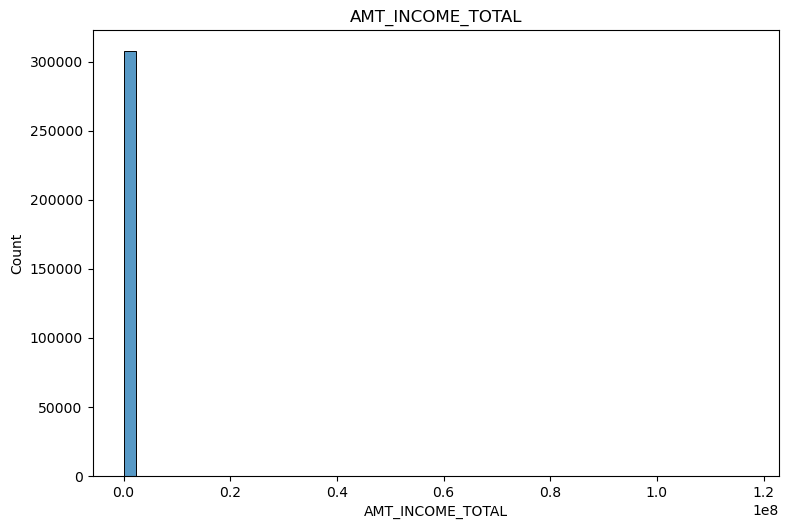

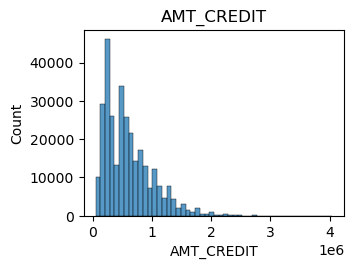

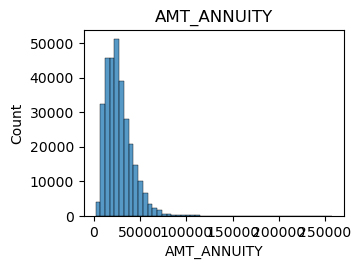

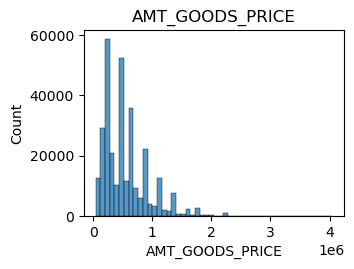

In [28]:
plt.figure(figsize=(15,10))
num_cols_to_plot = ['AMT_INCOME_TOTAL','AMT_CREDIT','AMT_ANNUITY','AMT_GOODS_PRICE']
for i, col in enumerate(num_cols_to_plot,1):
    plt.subplot(2,2,i)
    sns.histplot(app_df_clean[col],bins=50)
    plt.title(col)
    plt.tight_layout()
    plt.show()

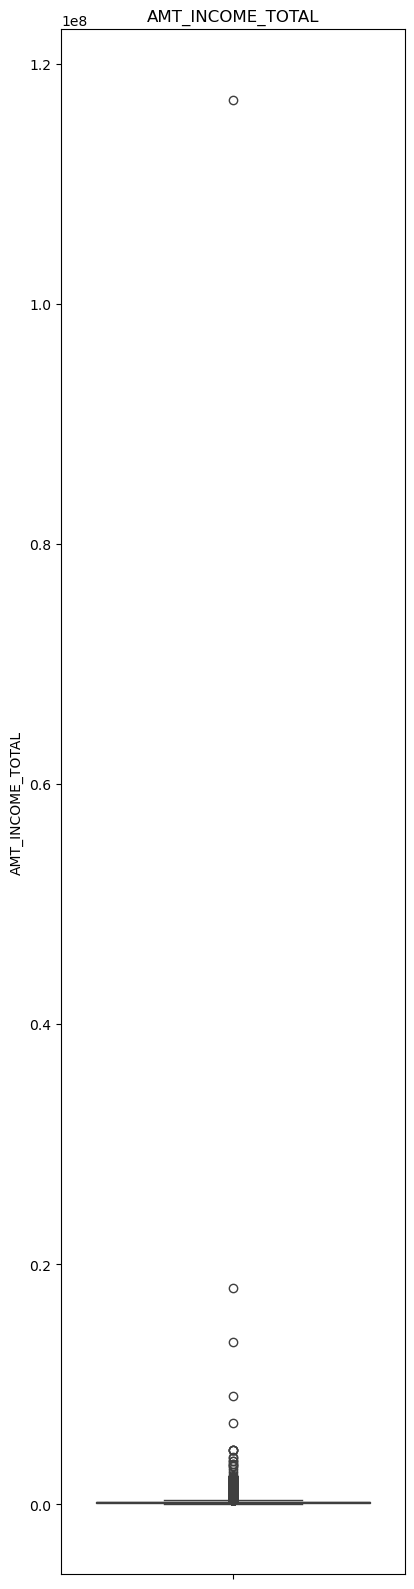

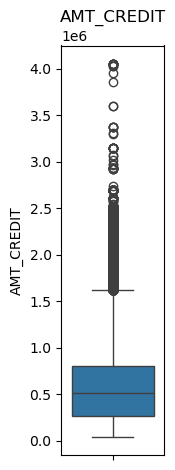

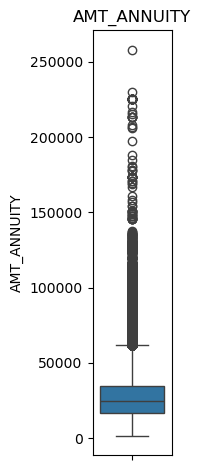

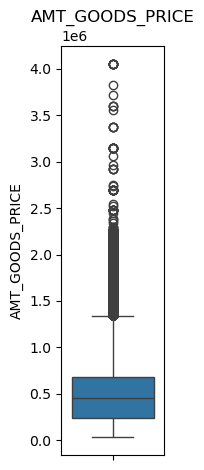

In [21]:
plt.figure(figsize=(15,16))
for i, col in enumerate(num_cols_to_plot, 1):
    plt.subplot(1,4,i)
    sns.boxplot(y=app_df_clean[col])
    plt.title(col)
    plt.tight_layout()
    plt.show()

### Observation from Numerical Distributions
1. Histograms clearly shows strong right skewness in income, credit, annuity and good prices variables.
2. Most applicants fall in lower value ranges, with small number of extreme high-value observations.
3. Boxplots highlight the presence of multiple outliers across monetary variablesw.
4. The Visual insights support the need for transformation or outlier  treatment before modeling.

## Univariate Analysis - Categorical Variables

In [23]:
cat_cols[:10]

Index(['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY',
       'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
       'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE'],
      dtype='object')

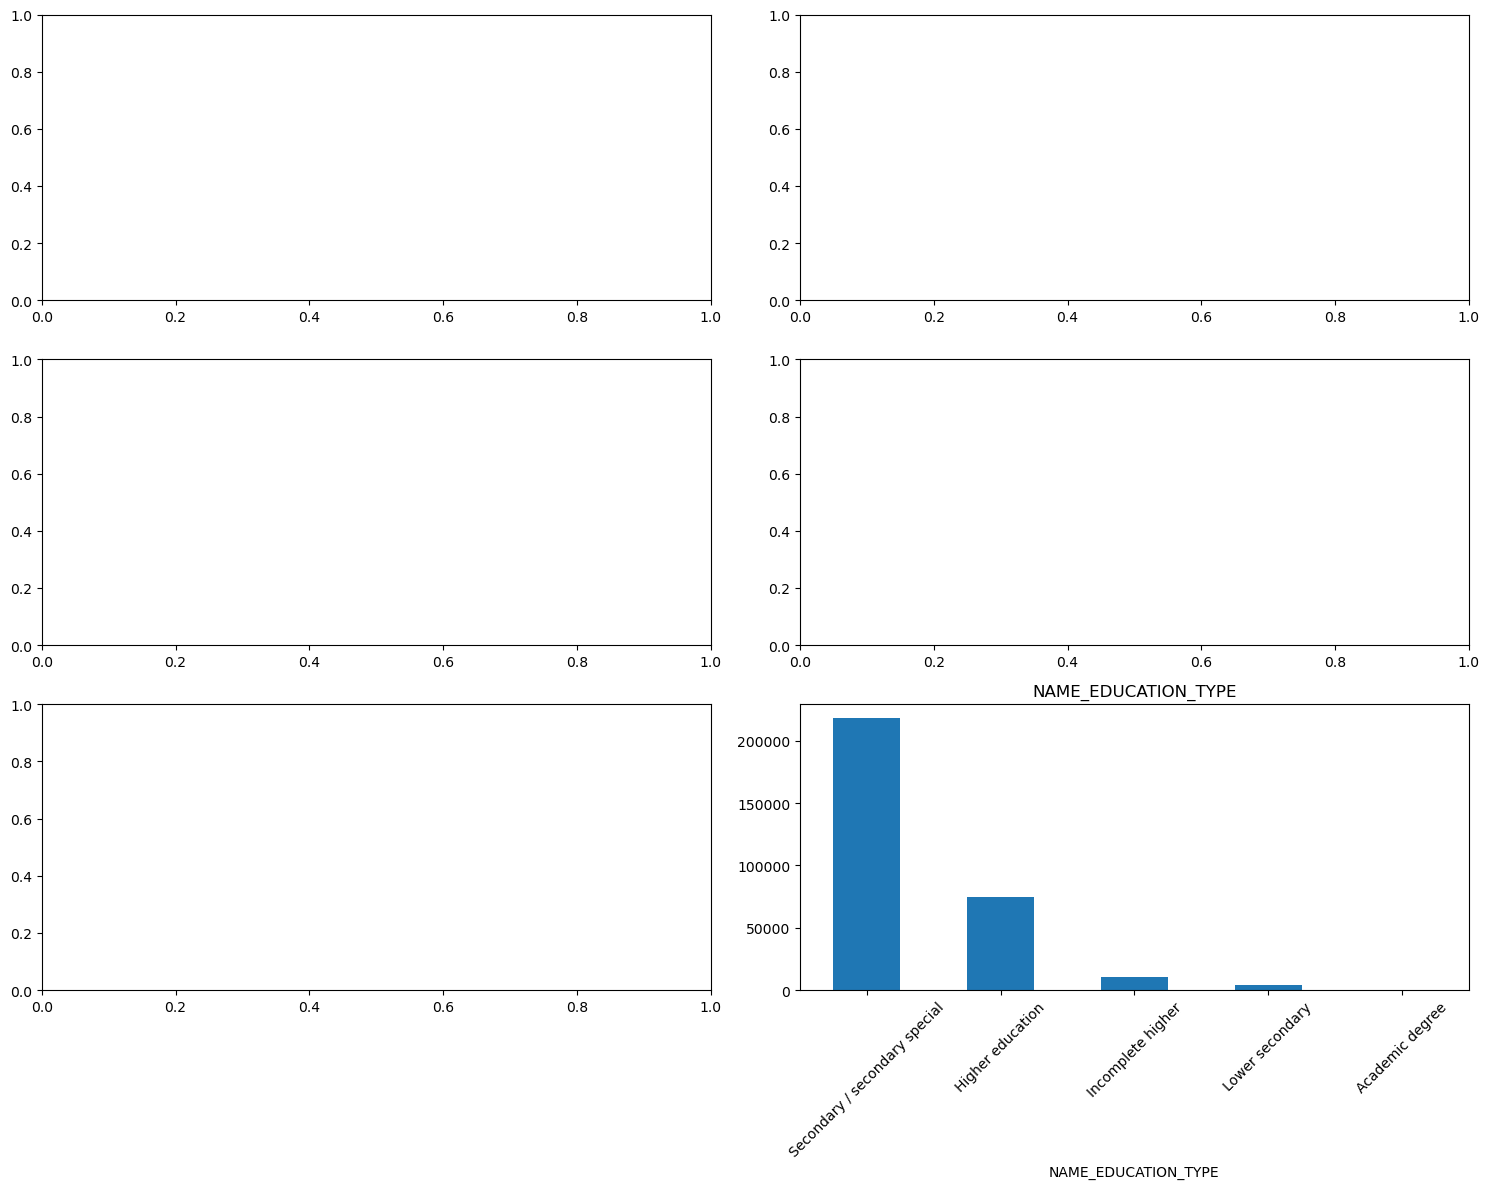

In [29]:
plt.figure(figsize=(15,12))
cat_cols_to_plot= ['NAME_CONTRACT_TYPE','CODE_GENDER','FLAG_OWN_CAR','FLAG_OWN_REALTY','NAME_INCOME_TYPE','NAME_EDUCATION_TYPE']
for i, col in enumerate(cat_cols_to_plot,1):
    plt.subplot(3,2,i)
app_df_clean[col].value_counts().plot(kind='bar')
plt.title(col)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Observation from Categorical Variables
1. Cash loans are the most common contract type.
2. Female Applicants slightly outnumber male applicants
3. Majority of applicants do not own a car.
4. Most applicants own real estate.
5. Secondary and higher education dominate the applicant pool.
6. Working professionals from the largest income group.

## Bivariate Analysis

### Numerical Variables vs Target

In [30]:
num_cols_bi  = ['AMT_INCOME_TOTAL','AMT_CREDIT','AMT_ANNUITY','AMT_GOODS_PRICE']
print(num_cols_bi)

['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE']


In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
    

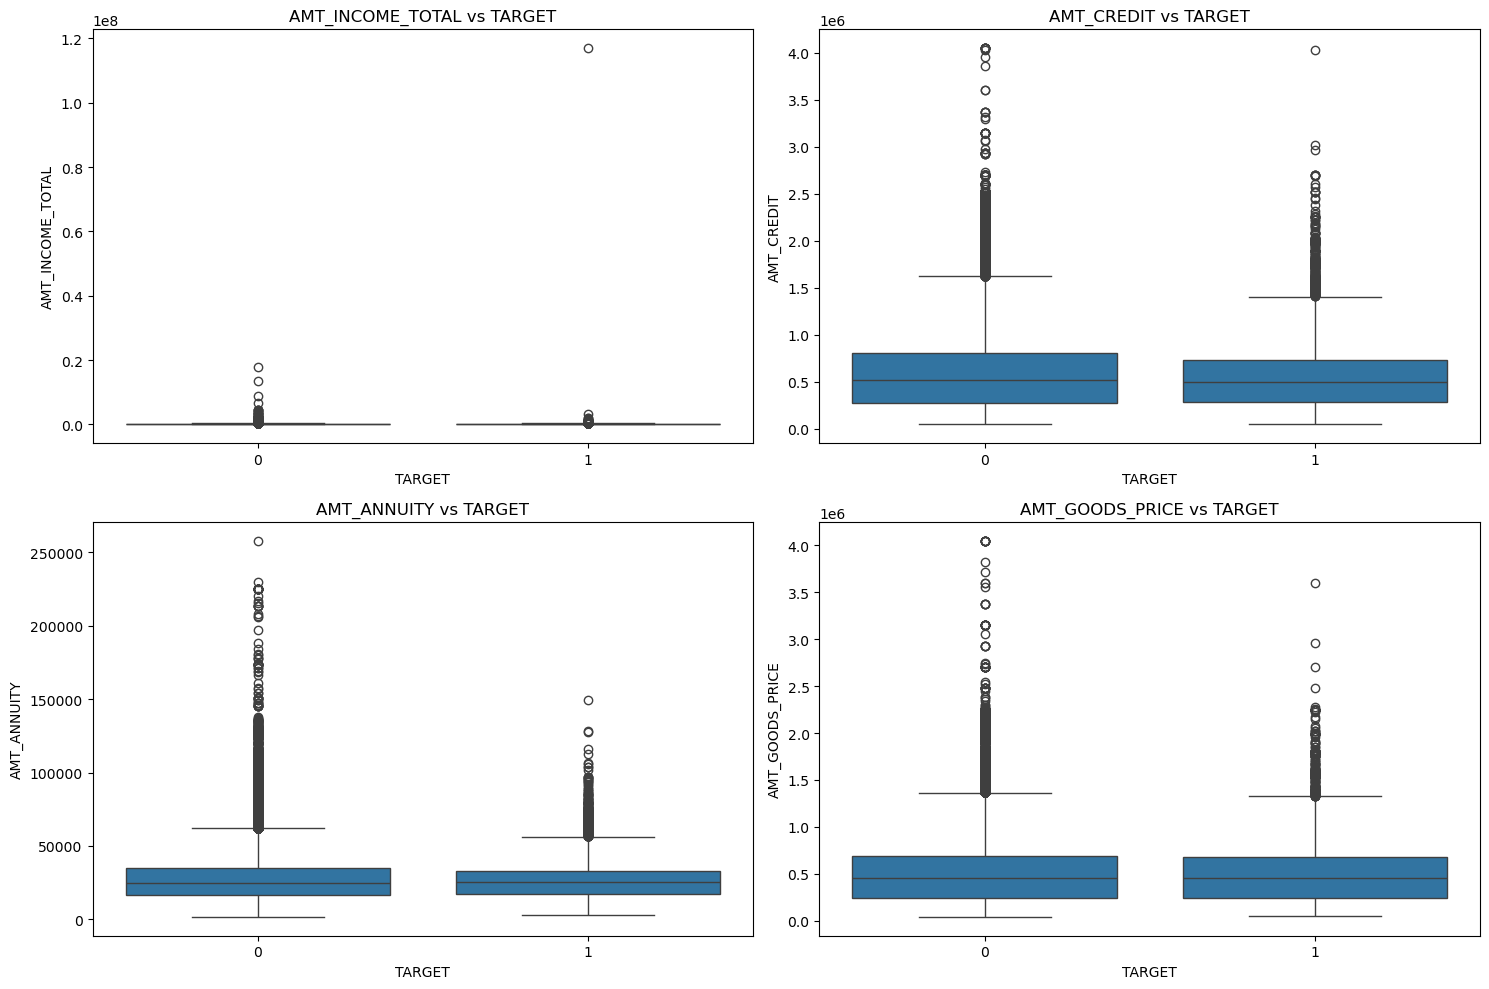

In [33]:
plt.figure(figsize=(15,10))
for i, col in enumerate(num_cols_bi,1):
    plt.subplot(2,2,i)
    sns.boxplot(x='TARGET',y=col,data=app_df_clean[[col,'TARGET']].dropna())
    plt.title(f'{col} vs TARGET')
plt.tight_layout()
plt.show()

### Observation from Numerical Variables vs Target
1. Clients with payment difficulties(TARGET=1) tend to have lower income and credit amounts.
2. Annuity values for defaulters are generally lower compared to non-defaulters.
3. All monetary variables show strong outliers across both target classes.
4. These features are important indicators of credit risk and may require transformation or capping.

## Bivariate Analysis - Categorical Variables vs Target

In [36]:
cat_cols_bi=['NAME_CONTRACT_TYPE','CODE_GENDER','FLAG_OWN_REALTY','NAME_EDUCATION_TYPE','NAME_INCOME_TYPE']
cat_cols_bi

['NAME_CONTRACT_TYPE',
 'CODE_GENDER',
 'FLAG_OWN_REALTY',
 'NAME_EDUCATION_TYPE',
 'NAME_INCOME_TYPE']

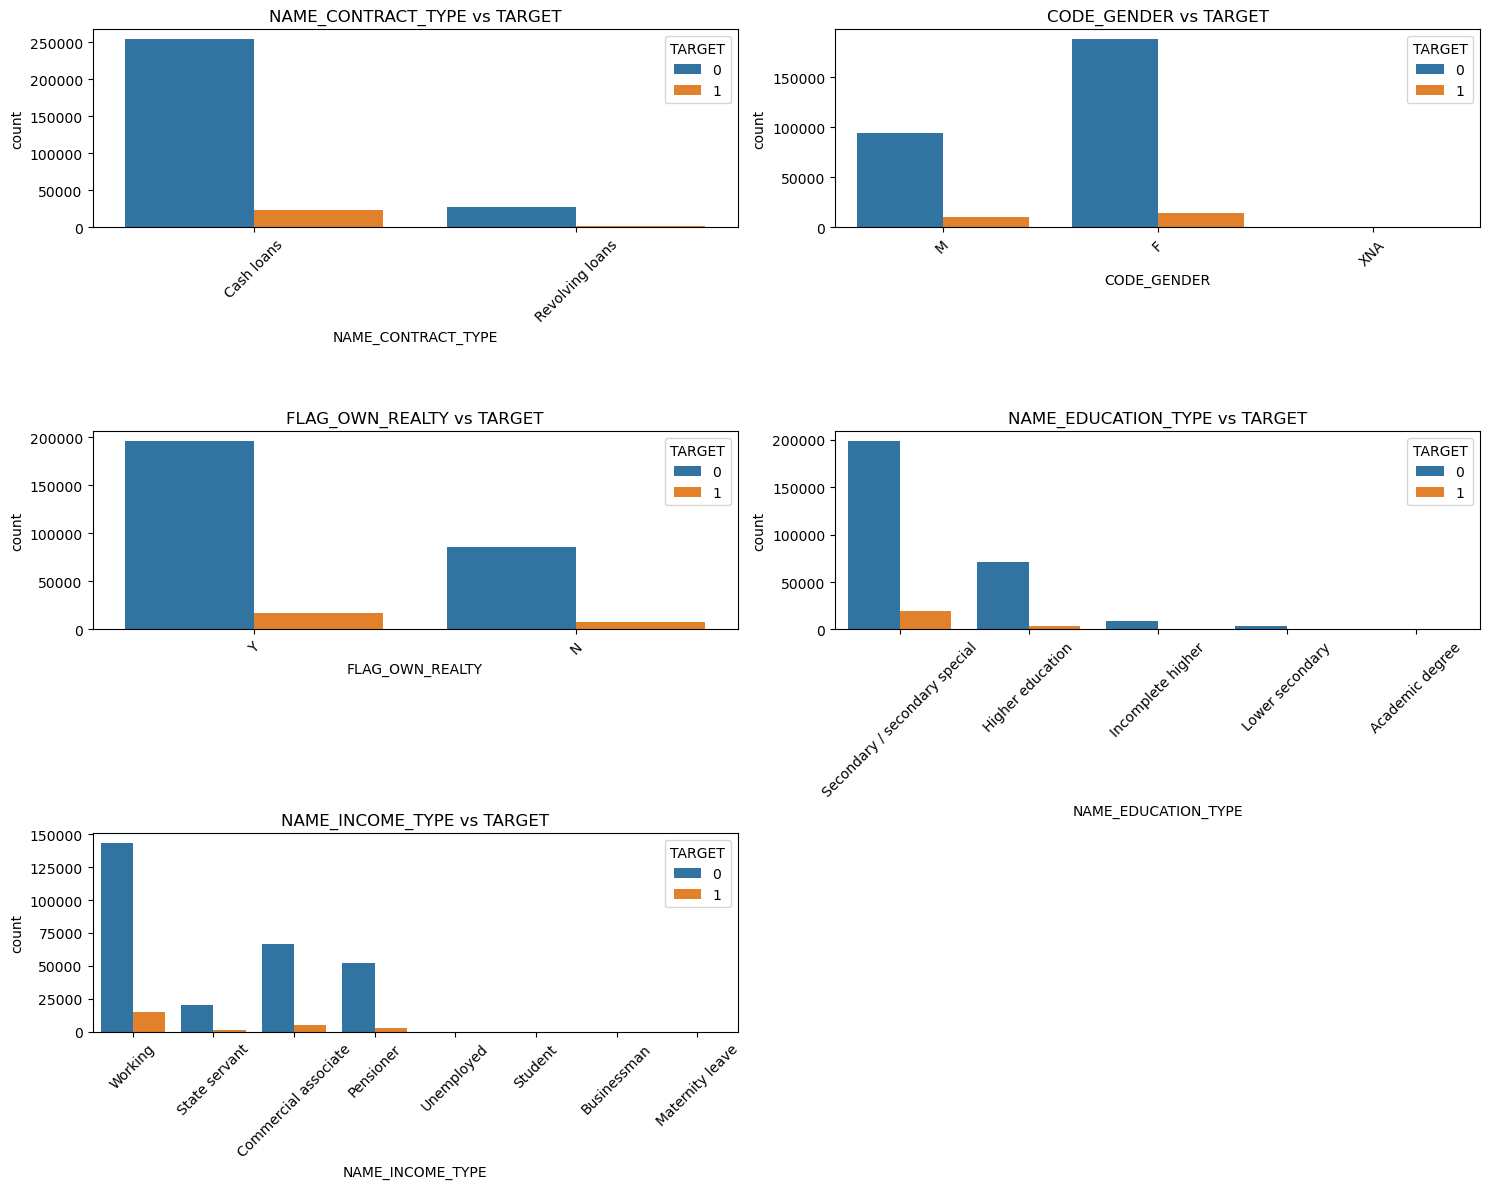

In [38]:
plt.figure(figsize=(15,12))
for i, col in enumerate(cat_cols_bi,1):
    plt.subplot(3,2,i)
    sns.countplot(x=col,hue='TARGET',data=app_df_clean)
    plt.xticks(rotation=45)
    plt.title(f'{col} vs TARGET')
    plt.tight_layout()
plt.show()

### Observation from Categorical Variables vs Target
1. Cash loan applicants show higher default counts compared to revolving loans.
2. Male applicants have slightly higher proportion of defaults than female applicants.
3. Applicants with lower education levels show higher default tendencies.
4. Income type plays a role in default risk, with working-class applicants forming the largest default group.
5. Ownership of real estate is associated with relatively lower default risk.

### Final Conclusion
From the above exploratory data analysis, we can see clear differnces between clients who face payment difficulties and those who do not.
Applicants with lower income, lower credit amounts,and lower values tend to show a higher risk of default. Most , monetary  variables are highly skewed and contain several extreme values which indicates the presence of outliers. These financial variable plays a crucial role in understanding a clients repayment capacity.
Categorical analysis shows that facrors such as contract type , education level,income types from a larger share of defaulters.Ownership of real estate appears to be associated with relatively lower default risk.
Overall,both numerical and categorical variables contribute valuable insights into identifying risky loan applicants.

### Business Recommendations
1. Lending company should carefully evaluate applicants with low income and low annuity values, as they show a higher tendency to default.
2. Extra attention should be given to applicants from income groups that show high default rates especially working-class and lower income segments.
3. Education level can be used an important supporting factor while assessing creditworthiness.
4. Applicants who own assest such as real estate generally show low risk and can be considered more reliable.
5. Outliers in income and credit- related variables should be handled properly before building predective models to improve accuracy.
6. Combining both financial and demographic information will help the company make better loan approval decisions and reduce credit risk.